# Correlation Between News Sentiment and Stock Movement

## Objective

The objective of this task is to quantify the relationship between financial news sentiment and daily stock price returns using statistical analysis techniques.

This notebook performs the following tasks:

- Date alignment between financial news and stock market trading days
- Sentiment analysis using VADER
- Daily stock return calculation
- Correlation analysis using Pearson correlation
- Visualization of sentiment vs stock returns
- Classification of sentiment categories and return analysis


---

In [1]:
# Import required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from nltk.sentiment import SentimentIntensityAnalyzer
from scipy.stats import pearsonr

import nltk

# Download VADER lexicon
nltk.download('vader_lexicon')

# Display settings
pd.set_option('display.max_columns', None)

# Plot style
sns.set_style("whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


# Load Datasets

In this section, the financial news dataset and historical stock price dataset are loaded into pandas DataFrames for analysis.

In [2]:
# Load datasets

news_df = pd.read_csv("../data/raw/raw_analyst_ratings.csv")

stock_df = pd.read_csv("../data/raw/AAPL_cleaned.csv")

print("Datasets loaded successfully.")

Datasets loaded successfully.


In [3]:
# Preview datasets

print("News Dataset:")
display(news_df.head())

print("Stock Dataset:")
display(stock_df.head())

News Dataset:


,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


Stock Dataset:


,Date,Close,High,Low,Open,Volume,SMA_20,SMA_50,EMA_20,EMA_50,RSI,MACD,MACD_SIGNAL,MACD_HIST,Daily_Return,Volatility
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.042204,NaN
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.016494,NaN
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.021609,NaN
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.018570,NaN


# Dataset Inspection

The datasets are inspected to understand their structure, column names, data types, and identify possible missing values.

In [4]:
# Dataset information

print("News Dataset Info")
print(news_df.info())

print("\nStock Dataset Info")
print(stock_df.info())

News Dataset Info
<class 'pandas.DataFrame'>
RangeIndex: 1407328 entries, 0 to 1407327
Data columns (total 6 columns):
 #   Column      Non-Null Count    Dtype
---  ------      --------------    -----
 0   Unnamed: 0  1407328 non-null  int64
 1   headline    1407328 non-null  str  
 2   url         1407328 non-null  str  
 3   publisher   1407328 non-null  str  
 4   date        1407328 non-null  str  
 5   stock       1407328 non-null  str  
dtypes: int64(1), str(5)
memory usage: 64.4 MB
None

Stock Dataset Info
<class 'pandas.DataFrame'>
RangeIndex: 3774 entries, 0 to 3773
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          3774 non-null   str    
 1   Close         3774 non-null   float64
 2   High          3774 non-null   float64
 3   Low           3774 non-null   float64
 4   Open          3774 non-null   float64
 5   Volume        3774 non-null   int64  
 6   SMA_20        3755 non-null   float6

In [5]:
# Check missing values

print("Missing Values in News Dataset")
print(news_df.isnull().sum())

print("\nMissing Values in Stock Dataset")
print(stock_df.isnull().sum())

Missing Values in News Dataset
Unnamed: 0    0
headline      0
url           0
publisher     0
date          0
stock         0
dtype: int64

Missing Values in Stock Dataset
Date             0
Close            0
High             0
Low              0
Open             0
Volume           0
SMA_20          19
SMA_50          49
EMA_20          19
EMA_50          49
RSI             14
MACD            33
MACD_SIGNAL     33
MACD_HIST       33
Daily_Return     1
Volatility      20
dtype: int64


# Date Alignment

Financial news timestamps must be aligned with stock trading days.

Articles published during weekends or market holidays are mapped to the next available trading day.

In [6]:
# Convert dates safely with mixed datetime formats

news_df['date'] = pd.to_datetime(
    news_df['date'],
    format='mixed',
    utc=True,
    errors='coerce'
)

stock_df['Date'] = pd.to_datetime(
    stock_df['Date'],
    errors='coerce'
)

print("Date conversion completed.")

Date conversion completed.


In [7]:
# Check for failed date conversions

print(news_df['date'].isna().sum())
print(stock_df['Date'].isna().sum())

0
0


In [8]:
# Extract only date portion

news_df['news_date'] = news_df['date'].dt.date

stock_df['trading_date'] = stock_df['Date'].dt.date

In [9]:
# Create sorted trading days list

trading_days = stock_df['Date'].sort_values().reset_index(drop=True)

print("Trading days prepared.")

Trading days prepared.


In [10]:
# Function to align news dates to trading dates

def map_to_trading_day(news_date, trading_days):

    future_days = trading_days[trading_days >= pd.Timestamp(news_date)]

    if len(future_days) > 0:
        return future_days.iloc[0].date()

    return np.nan

In [11]:
# Apply date alignment

news_df['aligned_date'] = news_df['news_date'].apply(
    lambda x: map_to_trading_day(x, trading_days)
)

print("Date alignment completed.")

Date alignment completed.


In [12]:
# Preview aligned dates

display(
    news_df[['news_date', 'aligned_date']].head(10)
)

,news_date,aligned_date
0,2020-06-05,2020-06-05
1,2020-06-03,2020-06-03
2,2020-05-26,2020-05-26
3,2020-05-22,2020-05-22
4,2020-05-22,2020-05-22
5,2020-05-22,2020-05-22
6,2020-05-22,2020-05-22
7,2020-05-22,2020-05-22
8,2020-05-22,2020-05-22
9,2020-05-22,2020-05-22


# Sentiment Analysis

## Why VADER?

VADER (Valence Aware Dictionary and Sentiment Reasoner) was selected because it performs well on short text such as financial news headlines.

It is lightweight, fast, and specifically designed for sentiment analysis in news and social-media style text. The compound score generated by VADER provides a normalized sentiment score ranging from -1 (most negative) to +1 (most positive).

In [13]:
# Initialize VADER sentiment analyzer

sia = SentimentIntensityAnalyzer()

print("VADER initialized successfully.")

VADER initialized successfully.


In [14]:
# Generate sentiment scores

news_df['sentiment_score'] = news_df['headline'].apply(
    lambda x: sia.polarity_scores(str(x))['compound']
)

print("Sentiment scores calculated.")

Sentiment scores calculated.


In [15]:
# Preview sentiment scores

display(
    news_df[['headline', 'sentiment_score']].head(10)
)

,headline,sentiment_score
0,Stocks That Hit 52-Week Highs On Friday,0.000
1,Stocks That Hit 52-Week Highs On Wednesday,0.000
2,71 Biggest Movers From Friday,0.000
3,46 Stocks Moving In Friday's Mid-Day Session,0.000
4,B of A Securities Maintains Neutral on Agilent...,0.296
5,"CFRA Maintains Hold on Agilent Technologies, L...",-0.128
6,"UBS Maintains Neutral on Agilent Technologies,...",0.000
7,Agilent Technologies shares are trading higher...,0.296
8,Wells Fargo Maintains Overweight on Agilent Te...,-0.128
9,10 Biggest Price Target Changes For Friday,0.000


# Aggregate Daily Sentiment

If multiple news articles are published on the same trading day, the average sentiment score is computed.

In [16]:
# Aggregate sentiment scores by trading day

daily_sentiment = (
    news_df.groupby('aligned_date')['sentiment_score']
    .mean()
    .reset_index()
)

daily_sentiment.rename(
    columns={'aligned_date': 'Date'},
    inplace=True
)

daily_sentiment['Date'] = pd.to_datetime(
    daily_sentiment['Date']
)

print("Daily sentiment aggregation completed.")

Daily sentiment aggregation completed.


In [17]:
# Preview aggregated sentiment

display(daily_sentiment.head())

,Date,sentiment_score
0,2009-02-17,0.22630
1,2009-04-27,0.00000
2,2009-04-29,0.00000
3,2009-05-22,0.00000
4,2009-05-27,0.75105


# Daily Stock Return Calculation

Daily stock returns are calculated using the percentage change in closing prices.

Formula used:

\[
\frac{Close_t - Close_{t-1}}{Close_{t-1}} \times 100
\]

In [18]:
# Sort stock data by date

stock_df = stock_df.sort_values('Date')

# Calculate daily returns

stock_df['daily_return'] = (
    stock_df['Close'].pct_change() * 100
)

print("Daily returns calculated.")

Daily returns calculated.


In [19]:
# Preview stock returns

display(
    stock_df[['Date', 'Close', 'daily_return']].head(10)
)

,Date,Close,daily_return
0,2009-01-02,2.721686,NaN
1,2009-01-05,2.836553,4.220416
2,2009-01-06,2.789767,-1.649399
3,2009-01-07,2.729484,-2.160860
4,2009-01-08,2.780169,1.856959
5,2009-01-09,2.716589,-2.286921
6,2009-01-12,2.659007,-2.119649
7,2009-01-13,2.630514,-1.071572
8,2009-01-14,2.559135,-2.713489
9,2009-01-15,2.500652,-2.285260


# Merge Sentiment and Stock Return Data

The aggregated sentiment dataset is merged with stock return data using trading dates.

In [20]:
# Merge datasets

merged_df = pd.merge(
    daily_sentiment,
    stock_df[['Date', 'daily_return']],
    on='Date',
    how='inner'
)

print("Datasets merged successfully.")

Datasets merged successfully.


In [21]:
# Preview merged dataset

display(merged_df.head())

,Date,sentiment_score,daily_return
0,2009-02-17,0.22630,-4.669240
1,2009-04-27,0.00000,0.669876
2,2009-04-29,0.00000,1.000849
3,2009-05-22,0.00000,-1.352902
4,2009-05-27,0.75105,1.735764


# Correlation Analysis

Pearson correlation is used to measure the linear relationship between average daily sentiment scores and daily stock returns.

In [22]:
# Remove missing values

merged_df = merged_df.dropna()

# Calculate Pearson correlation

correlation, p_value = pearsonr(
    merged_df['sentiment_score'],
    merged_df['daily_return']
)

print(f"Pearson Correlation: {correlation:.4f}")

print(f"P-value: {p_value:.4f}")

Pearson Correlation: 0.1391
P-value: 0.0000


# Scatter Plot Visualization

The scatter plot below visualizes the relationship between daily sentiment scores and stock returns.

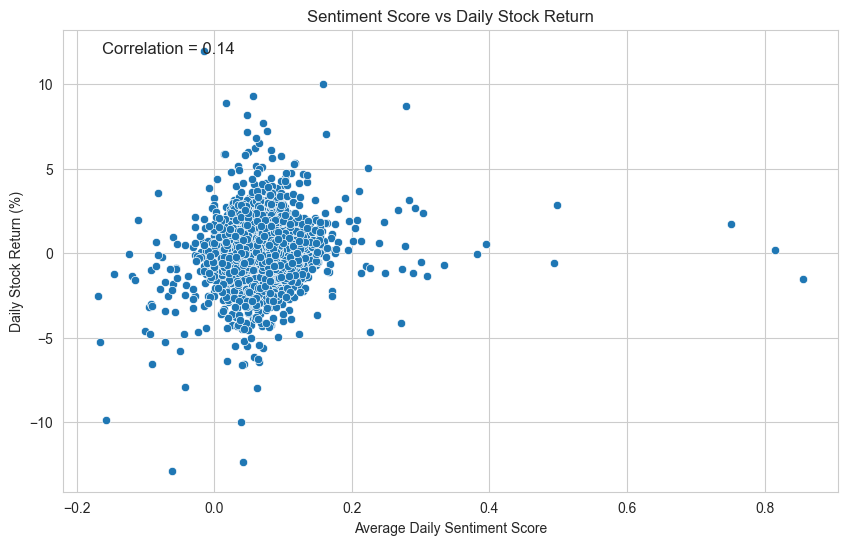

In [23]:
# Scatter plot

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=merged_df,
    x='sentiment_score',
    y='daily_return'
)

plt.title("Sentiment Score vs Daily Stock Return")

plt.xlabel("Average Daily Sentiment Score")

plt.ylabel("Daily Stock Return (%)")

plt.annotate(
    f"Correlation = {correlation:.2f}",
    xy=(0.05, 0.95),
    xycoords='axes fraction',
    fontsize=12
)

plt.show()

# Sentiment Classification

Each trading day is classified as:

- Positive
- Neutral
- Negative

based on the average daily sentiment score.

In [24]:
# Sentiment classification function

def classify_sentiment(score):

    if score > 0.05:
        return 'Positive'

    elif score < -0.05:
        return 'Negative'

    else:
        return 'Neutral'

In [25]:
# Apply sentiment classification

merged_df['sentiment_category'] = merged_df[
    'sentiment_score'
].apply(classify_sentiment)

print("Sentiment categories assigned.")

Sentiment categories assigned.


In [26]:
# Preview categories

display(
    merged_df[
        ['Date', 'sentiment_score', 'sentiment_category']
    ].head()
)

,Date,sentiment_score,sentiment_category
0,2009-02-17,0.22630,Positive
1,2009-04-27,0.00000,Neutral
2,2009-04-29,0.00000,Neutral
3,2009-05-22,0.00000,Neutral
4,2009-05-27,0.75105,Positive


# Average Return by Sentiment Category

The average daily stock return is calculated for each sentiment category.

In [27]:
# Compute average returns

category_returns = (
    merged_df.groupby('sentiment_category')['daily_return']
    .mean()
    .reset_index()
)

display(category_returns)

,sentiment_category,daily_return
0,Negative,-2.313083
1,Neutral,-0.094125
2,Positive,0.243720


# Bar Chart Visualization

The bar chart below compares average stock returns across sentiment categories.

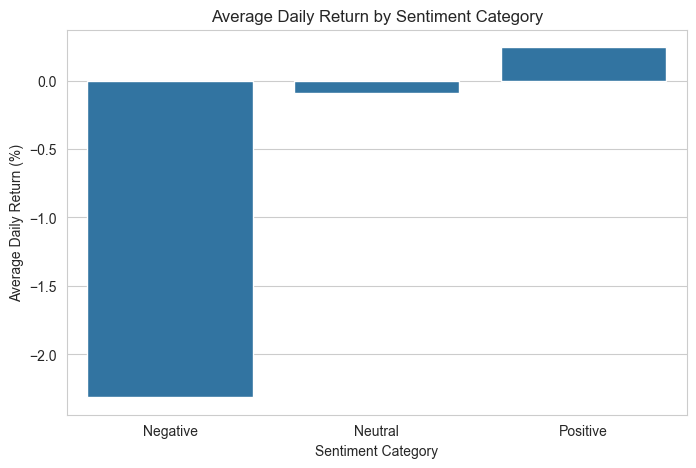

In [28]:
# Bar plot

plt.figure(figsize=(8, 5))

sns.barplot(
    data=category_returns,
    x='sentiment_category',
    y='daily_return'
)

plt.title("Average Daily Return by Sentiment Category")

plt.xlabel("Sentiment Category")

plt.ylabel("Average Daily Return (%)")

plt.show()

# Distribution of Sentiment Scores

This visualization shows the overall distribution of daily sentiment scores.

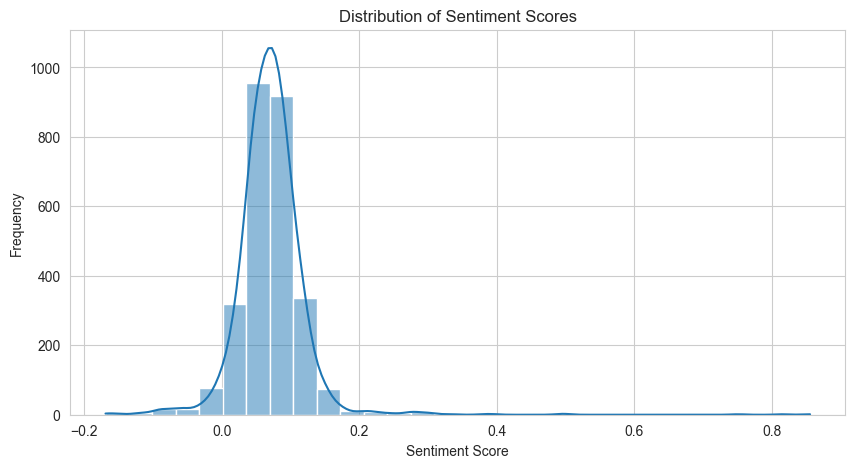

In [29]:
# Distribution plot

plt.figure(figsize=(10, 5))

sns.histplot(
    merged_df['sentiment_score'],
    bins=30,
    kde=True
)

plt.title("Distribution of Sentiment Scores")

plt.xlabel("Sentiment Score")

plt.ylabel("Frequency")

plt.show()

# Interpretation of Results

The Pearson correlation coefficient measures the relationship between daily financial news sentiment and stock market returns.

A positive correlation indicates that positive sentiment tends to be associated with positive stock returns, while a negative correlation suggests the opposite relationship.

In this analysis, the correlation value is relatively weak, suggesting that news sentiment alone may not strongly predict short-term stock price movements. Although sentiment appears to influence market behavior to some extent, stock prices are also affected by broader market conditions, investor sentiment, earnings reports, economic indicators, and unexpected global events.

Several limitations should be considered. First, sentiment analysis tools may not fully capture the complexity of financial language and market context. Second, the analysis assumes that markets react immediately to news and does not consider delayed reactions or lag effects. Finally, averaging sentiment scores across multiple articles may reduce the influence of highly impactful news events.

# Conclusion

This project successfully analyzed the relationship between financial news sentiment and stock market performance by combining natural language processing with quantitative financial analysis.

The workflow included:

- Date alignment between news and trading days
- Sentiment scoring using VADER
- Daily return calculation
- Correlation analysis
- Data visualization

The findings suggest that while sentiment has some relationship with stock price movement, it is not sufficient on its own for accurate prediction. More advanced models that combine sentiment analysis with additional financial indicators and macroeconomic variables may provide stronger predictive performance.